<a href="https://colab.research.google.com/github/02falgun/Be-Practical-Assessments/blob/main/Tasks_Day_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Student Model with Early Stopping...
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 6.


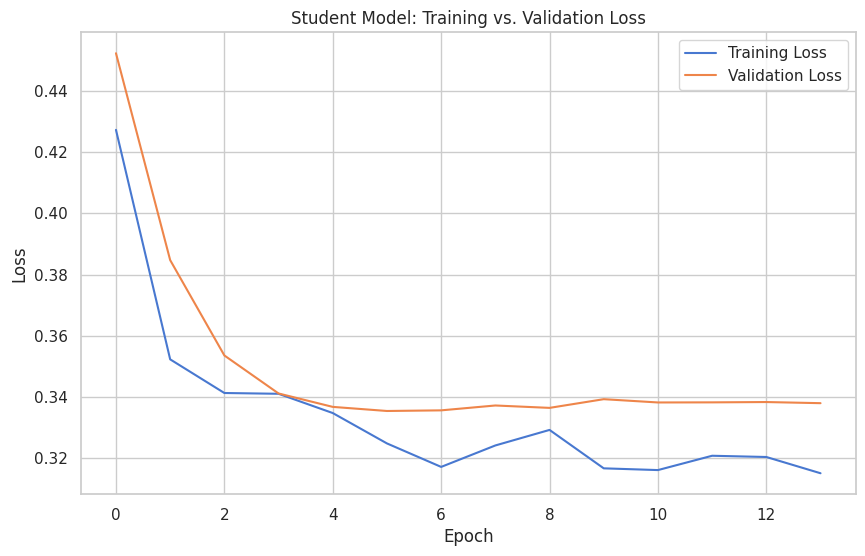

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Student Model Test Set Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       310
           1       0.85      0.82      0.84       290

    accuracy                           0.84       600
   macro avg       0.85      0.84      0.84       600
weighted avg       0.85      0.84      0.84       600

ROC-AUC Score: 0.9309


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

# ------------------------------------------------------------------------------
# Dataset Generation
# ------------------------------------------------------------------------------
np.random.seed(42)
N = 3000

credit_score = np.random.normal(loc=650, scale=80, size=N).clip(300, 850)
annual_income = np.random.lognormal(mean=10.8, sigma=0.6, size=N).clip(20000, 300000)
loan_amount = np.random.normal(loc=25000, scale=12000, size=N).clip(2000, 80000)
debt_to_income = (loan_amount / annual_income) * np.random.uniform(0.8, 1.4, size=N)
employment_years = np.random.exponential(scale=6, size=N).clip(0, 40).astype(int)
missed_payments_2yr = np.random.poisson(lam=0.8, size=N)

risk_logits = (
    1.2
    - 0.008 * credit_score
    - 0.000015 * annual_income
    + 0.00004 * loan_amount
    + 3.2 * debt_to_income
    - 0.08 * employment_years
    + 0.95 * missed_payments_2yr
    + 0.0001 * (loan_amount * debt_to_income)
)
default_prob = 1 / (1 + np.exp(-risk_logits))
default_label = np.where(np.random.rand(N) < default_prob, 1, 0)

df_loan = pd.DataFrame({
    "Credit_Score": np.round(credit_score, 0),
    "Annual_Income_USD": np.round(annual_income, 2),
    "Loan_Amount_USD": np.round(loan_amount, 2),
    "Debt_to_Income_Ratio": np.round(debt_to_income, 4),
    "Employment_Years": employment_years,
    "Missed_Payments_2Yr": missed_payments_2yr,
    "Default": default_label
})

df_loan.to_csv("loan_default_nn.csv", index=False)

# Data Preparation
X = df_loan.drop(columns=["Default"])
y = df_loan["Default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------------------
# STUDENT GRADED LAB ASSIGNMENT
# ------------------------------------------------------------------------------

# 1. Model Architecture
student_model = Sequential([
    Dense(48, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2. Compile Model
student_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Early Stopping Callback & Training
early_stop_student = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print("Training Student Model with Early Stopping...")
history_student = student_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_student],
    verbose=0
)

# 4. Plot Training vs Validation Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history_student.history['loss'], label='Training Loss')
plt.plot(history_student.history['val_loss'], label='Validation Loss')
plt.title('Student Model: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 5. Evaluate on Holdout Test Set
student_predictions_proba = student_model.predict(X_test_scaled)
student_predictions = (student_predictions_proba >= 0.5).astype(int)

print("\n--- Student Model Test Set Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, student_predictions))

roc_auc = roc_auc_score(y_test, student_predictions_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

In [7]:
!pip install gensim
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import gensim.downloader as api

# 0. Setup Dataset and Embeddings
data = {
    'Text': [
        'I want to cancel my subscription', 'How do I terminate my account?', 'Please stop my billing',
        'How can I reset my password?', 'Locked out of my account', 'Need help with login',
        'Why was I charged twice?', 'I need a refund for this month', 'Billing statement is wrong',
        'The app is crashing on startup', 'Technical issue with the dashboard', 'Error code 500 on checkout'
    ],
    'Category': [
        'Cancellation', 'Cancellation', 'Cancellation',
        'Account', 'Account', 'Account',
        'Billing', 'Billing', 'Billing',
        'Technical', 'Technical', 'Technical'
    ]
}
df_nlp = pd.DataFrame(data)

# Load small GloVe vectors
print("Loading GloVe vectors...")
glove_vectors = api.load("glove-wiki-gigaword-50")

def get_sentence_embedding(text, model):
    words = text.lower().split()
    vectors = [model[w] for w in words if w in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# 1. Generate Feature Spaces

# Strategy A: Sparse TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_sparse = tfidf_vectorizer.fit_transform(df_nlp['Text'])

# Strategy B: Dense GloVe Matrix
X_dense = np.array([get_sentence_embedding(text, glove_vectors) for text in df_nlp['Text']])

y = df_nlp['Category']

# 2. Train/Test Splits
X_train_sparse, X_test_sparse, y_train_sparse, y_test_sparse = train_test_split(
    X_sparse, y, test_size=0.25, random_state=42
)

X_train_dense, X_test_dense, y_train_dense, y_test_dense = train_test_split(
    X_dense, y, test_size=0.25, random_state=42
)

# 3. Train Models
model_sparse = LogisticRegression(max_iter=1000)
model_sparse.fit(X_train_sparse, y_train_sparse)

model_dense = LogisticRegression(max_iter=1000)
model_dense.fit(X_train_dense, y_train_dense)

# 4. Predict & Benchmark
y_pred_sparse = model_sparse.predict(X_test_sparse)
y_pred_dense = model_dense.predict(X_test_dense)

print("\n=== STRATEGY A: SPARSE TF-IDF EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_sparse, y_pred_sparse):.4f}")
print(classification_report(y_test_sparse, y_pred_sparse))

print("\n=== STRATEGY B: DENSE GLOVE EMBEDDING EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_dense, y_pred_dense):.4f}")
print(classification_report(y_test_dense, y_pred_dense))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 22.0 MB/s eta 0:00:00
Loading GloVe vectors...
[==================================================] 100.0% 66.0/66.0MB downloaded

=== STRATEGY A: SPARSE TF-IDF EVALUATION ===
Accuracy: 0.0000
              precision    recall  f1-score   support

     Billing       0.00      0.00      0.00       0.0
Cancellation       0.00      0.00      0.00       1.0
   Technical       0.00      0.00      0.00       2.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


=== STRATEGY B: DENSE GLOVE EMBEDDING EVALUATION ===
Accuracy: 0.3333
              precision    recall  f1-score   support

     Account       0.00      0.00      0.00         0
Cancellation       1.00      1.00      1.00         1
   Technical       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.33   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [ ]:
!pip install gensim
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import gensim.downloader as api

# 0. Setup Dataset and Embeddings
data = {
    'Text': [
        'I want to cancel my subscription', 'How do I terminate my account?', 'Please stop my billing',
        'How can I reset my password?', 'Locked out of my account', 'Need help with login',
        'Why was I charged twice?', 'I need a refund for this month', 'Billing statement is wrong',
        'The app is crashing on startup', 'Technical issue with the dashboard', 'Error code 500 on checkout'
    ],
    'Category': [
        'Cancellation', 'Cancellation', 'Cancellation',
        'Account', 'Account', 'Account',
        'Billing', 'Billing', 'Billing',
        'Technical', 'Technical', 'Technical'
    ]
}
df_nlp = pd.DataFrame(data)

# Load small GloVe vectors
print("Loading GloVe vectors...")
glove_vectors = api.load("glove-wiki-gigaword-50")

def get_sentence_embedding(text, model):
    words = text.lower().split()
    vectors = [model[w] for w in words if w in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# 1. Generate Feature Spaces

# Strategy A: Sparse TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_sparse = tfidf_vectorizer.fit_transform(df_nlp['Text'])

# Strategy B: Dense GloVe Matrix
X_dense = np.array([get_sentence_embedding(text, glove_vectors) for text in df_nlp['Text']])

y = df_nlp['Category']

# 2. Train/Test Splits
X_train_sparse, X_test_sparse, y_train_sparse, y_test_sparse = train_test_split(
    X_sparse, y, test_size=0.25, random_state=42
)

X_train_dense, X_test_dense, y_train_dense, y_test_dense = train_test_split(
    X_dense, y, test_size=0.25, random_state=42
)

# 3. Train Models
model_sparse = LogisticRegression(max_iter=1000)
model_sparse.fit(X_train_sparse, y_train_sparse)

model_dense = LogisticRegression(max_iter=1000)
model_dense.fit(X_train_dense, y_train_dense)

# 4. Predict & Benchmark
y_pred_sparse = model_sparse.predict(X_test_sparse)
y_pred_dense = model_dense.predict(X_test_dense)

print("\n=== STRATEGY A: SPARSE TF-IDF EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_sparse, y_pred_sparse):.4f}")
print(classification_report(y_test_sparse, y_pred_sparse))

print("\n=== STRATEGY B: DENSE GLOVE EMBEDDING EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_dense, y_pred_dense):.4f}")
print(classification_report(y_test_dense, y_pred_dense))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 22.0 MB/s eta 0:00:00
Loading GloVe vectors...
[==================================================] 100.0% 66.0/66.0MB downloaded

=== STRATEGY A: SPARSE TF-IDF EVALUATION ===
Accuracy: 0.0000
              precision    recall  f1-score   support

     Billing       0.00      0.00      0.00       0.0
Cancellation       0.00      0.00      0.00       1.0
   Technical       0.00      0.00      0.00       2.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


=== STRATEGY B: DENSE GLOVE EMBEDDING EVALUATION ===
Accuracy: 0.3333
              precision    recall  f1-score   support

     Account       0.00      0.00      0.00         0
Cancellation       1.00      1.00      1.00         1
   Technical       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.33   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [ ]:
!pip install gensim
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import gensim.downloader as api

# 0. Setup Dataset and Embeddings
data = {
    'Text': [
        'I want to cancel my subscription', 'How do I terminate my account?', 'Please stop my billing',
        'How can I reset my password?', 'Locked out of my account', 'Need help with login',
        'Why was I charged twice?', 'I need a refund for this month', 'Billing statement is wrong',
        'The app is crashing on startup', 'Technical issue with the dashboard', 'Error code 500 on checkout'
    ],
    'Category': [
        'Cancellation', 'Cancellation', 'Cancellation',
        'Account', 'Account', 'Account',
        'Billing', 'Billing', 'Billing',
        'Technical', 'Technical', 'Technical'
    ]
}
df_nlp = pd.DataFrame(data)

# Load small GloVe vectors
print("Loading GloVe vectors...")
glove_vectors = api.load("glove-wiki-gigaword-50")

def get_sentence_embedding(text, model):
    words = text.lower().split()
    vectors = [model[w] for w in words if w in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# 1. Generate Feature Spaces

# Strategy A: Sparse TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_sparse = tfidf_vectorizer.fit_transform(df_nlp['Text'])

# Strategy B: Dense GloVe Matrix
X_dense = np.array([get_sentence_embedding(text, glove_vectors) for text in df_nlp['Text']])

y = df_nlp['Category']

# 2. Train/Test Splits
X_train_sparse, X_test_sparse, y_train_sparse, y_test_sparse = train_test_split(
    X_sparse, y, test_size=0.25, random_state=42
)

X_train_dense, X_test_dense, y_train_dense, y_test_dense = train_test_split(
    X_dense, y, test_size=0.25, random_state=42
)

# 3. Train Models
model_sparse = LogisticRegression(max_iter=1000)
model_sparse.fit(X_train_sparse, y_train_sparse)

model_dense = LogisticRegression(max_iter=1000)
model_dense.fit(X_train_dense, y_train_dense)

# 4. Predict & Benchmark
y_pred_sparse = model_sparse.predict(X_test_sparse)
y_pred_dense = model_dense.predict(X_test_dense)

print("\n=== STRATEGY A: SPARSE TF-IDF EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_sparse, y_pred_sparse):.4f}")
print(classification_report(y_test_sparse, y_pred_sparse))

print("\n=== STRATEGY B: DENSE GLOVE EMBEDDING EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_dense, y_pred_dense):.4f}")
print(classification_report(y_test_dense, y_pred_dense))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 22.0 MB/s eta 0:00:00
Loading GloVe vectors...
[==================================================] 100.0% 66.0/66.0MB downloaded

=== STRATEGY A: SPARSE TF-IDF EVALUATION ===
Accuracy: 0.0000
              precision    recall  f1-score   support

     Billing       0.00      0.00      0.00       0.0
Cancellation       0.00      0.00      0.00       1.0
   Technical       0.00      0.00      0.00       2.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


=== STRATEGY B: DENSE GLOVE EMBEDDING EVALUATION ===
Accuracy: 0.3333
              precision    recall  f1-score   support

     Account       0.00      0.00      0.00         0
Cancellation       1.00      1.00      1.00         1
   Technical       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.33   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

### 💼 Executive Brief: Semantic NLP Reflection

* **Synonym Handling:** Dense embeddings excel because they represent words in a continuous vector space where semantically similar words (like 'terminate' and 'cancel') have similar vectors, whereas TF-IDF relies on exact keyword matching.
* **Generalization Power:** Pre-trained embeddings like GloVe provide the model with prior linguistic knowledge, allowing it to understand customer intent even when the test data uses slightly different vocabulary than the training set.
* **Vector Efficiency:** By reducing text to a fixed-size dense vector (50 dimensions in this case) rather than a high-dimensional sparse vocabulary, the model becomes more robust to noise and better at capturing the 'gist' of a sentence.